<a href="https://colab.research.google.com/github/Pavarit2546/ML_project/blob/main/model_training/OUTLIER_Analysis_PregRiskPred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
maternal_health_risk = fetch_ucirepo(id=863)

# data (as pandas dataframes)
X = maternal_health_risk.data.features
y = maternal_health_risk.data.targets

# metadata
print(maternal_health_risk.metadata)

# variable information
print(maternal_health_risk.variables)


{'uci_id': 863, 'name': 'Maternal Health Risk', 'repository_url': 'https://archive.ics.uci.edu/dataset/863/maternal+health+risk', 'data_url': 'https://archive.ics.uci.edu/static/public/863/data.csv', 'abstract': 'Data has been collected from different hospitals, community clinics, maternal health cares from the rural areas of Bangladesh through the IoT based risk monitoring system.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1013, 'num_features': 6, 'feature_types': ['Real', 'Integer'], 'demographics': ['Age'], 'target_col': ['RiskLevel'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DP5D', 'creators': ['Marzia Ahmed'], 'intro_paper': {'ID': 274, 'type': 'NATIVE', 'title': 'Review and Analysis of Risk Factor of Maternal Health in Remote Area Using the Internet of Things (IoT)', 'authors':

In [ ]:
X.shape

(1014, 6)

In [ ]:
X.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,25,130,80,15.0,98.0,86
1,35,140,90,13.0,98.0,70
2,29,90,70,8.0,100.0,80
3,30,140,85,7.0,98.0,70
4,35,120,60,6.1,98.0,76


In [ ]:
X.isnull().sum()

,0
Age,0
SystolicBP,0
DiastolicBP,0
BS,0
BodyTemp,0
HeartRate,0


In [ ]:
y.head()

,RiskLevel
0,high risk
1,high risk
2,high risk
3,high risk
4,low risk


In [ ]:
y.isnull().sum()

,0
RiskLevel,0


ตรวจสอบ outliers

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

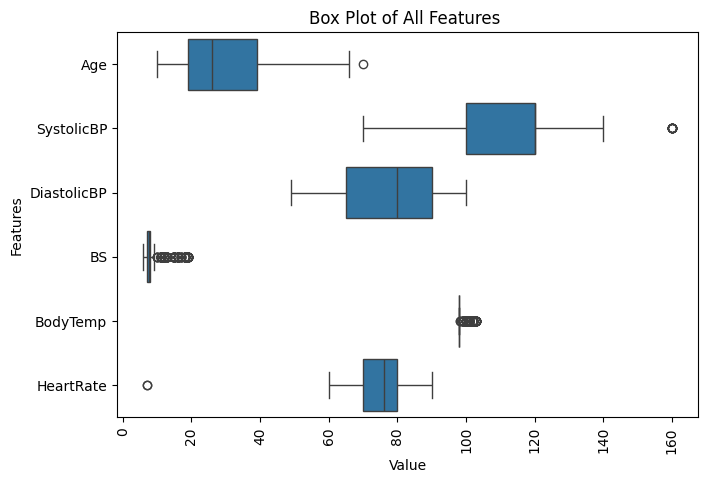

In [ ]:
# Melt the DataFrame
X_melted = X.melt(var_name='Features', value_name='Value')

# แสดง Box Plot สำหรับทุกคุณสมบัติ
sns.boxplot(y='Features', x='Value', data=X_melted)
plt.xticks(rotation=90)
plt.title('Box Plot of All Features ')
plt.show()

<Axes: xlabel='BS'>

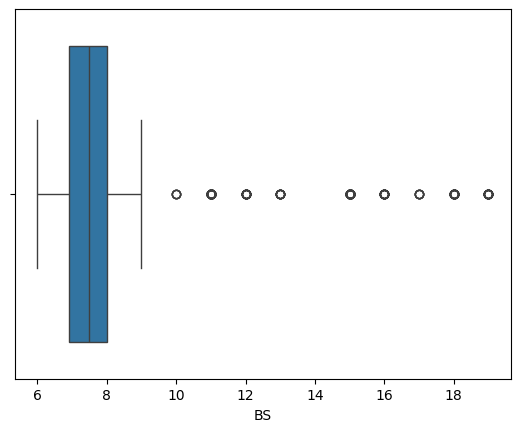

In [ ]:
sns.boxplot(x=X['BS'])

<Axes: xlabel='BodyTemp'>

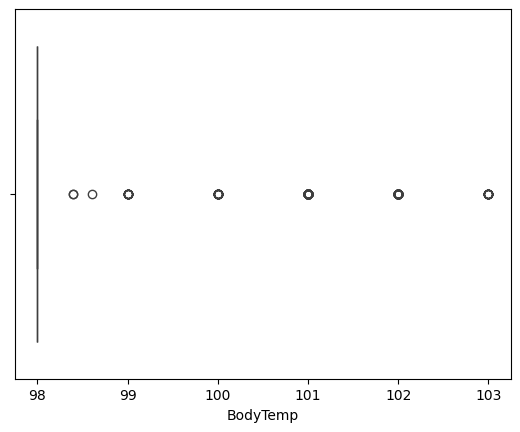

In [ ]:
sns.boxplot(x=X['BodyTemp'])

<Axes: xlabel='RiskLevel'>

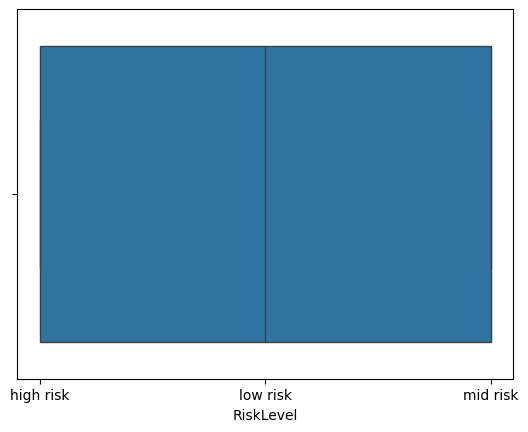

In [ ]:
sns.boxplot(x=y['RiskLevel'])

In [ ]:
def find_outliers_IQR(data , attr):
  # IQR
  q1 = data[attr].quantile(.25)
  q3 = data[attr].quantile(.75)
  # q1, q3 = nppercentile(data4.unit_price, [25,75])

  iqr= q3 - q1

  upper = q3 + (1.5*iqr)
  lower = q1 - (1.5*iqr)

  print('Q1 = {}'.format(q1))
  print('Q3 = {}'.format(q3))
  print('IQR = {}'.format(iqr))
  print('Upper = {:.2f}'.format(upper))
  print('Lower = {}'.format(lower))

  cnt = 0
  for i in data[attr]:
    if i > upper:
      #print(data[data[attr] == attr].index)
      cnt += 1
  print('Outliers Upper Total = {}'.format(cnt))

  cnt = 0
  for j in data[attr]:
    if j < lower:
      #print(data[data[attr] == attr].index)
      cnt += 1
  print('Outliers Lower Total = {}'.format(cnt))

In [ ]:
find_outliers_IQR(X, 'BS')

Q1 = 6.9
Q3 = 8.0
IQR = 1.0999999999999996
Upper = 9.65
Lower = 5.250000000000001
Outliers Upper Total = 210
Outliers Lower Total = 0


In [ ]:
find_outliers_IQR(X, 'BodyTemp')

Q1 = 98.0
Q3 = 98.0
IQR = 0.0
Upper = 98.00
Lower = 98.0
Outliers Upper Total = 210
Outliers Lower Total = 0


In [ ]:
find_outliers_IQR(X, 'Age')

Q1 = 19.0
Q3 = 39.0
IQR = 20.0
Upper = 69.00
Lower = -11.0
Outliers Upper Total = 1
Outliers Lower Total = 0


In [ ]:
find_outliers_IQR(X, 'SystolicBP')

Q1 = 100.0
Q3 = 120.0
IQR = 20.0
Upper = 150.00
Lower = 70.0
Outliers Upper Total = 10
Outliers Lower Total = 0


In [ ]:
find_outliers_IQR(X, 'HeartRate')

Q1 = 70.0
Q3 = 80.0
IQR = 10.0
Upper = 95.00
Lower = 55.0
Outliers Upper Total = 0
Outliers Lower Total = 2


In [ ]:
def RemoveOutliers(df,column):
  # IQR
  q1 = df[column].quantile(.25)
  q3 = df[column].quantile(.75)

  iqr= q3 - q1

  upper = q3 + (1.5*iqr)
  lower = q1 - (1.5*iqr)

  #return df[(df[column] >= lower) & (df[column] <= upper)]

  #ลบค่าผิดปกติเหนือขอบเขตบนและล่าง
  clean_df = df.drop(df[(df[column] > upper) | (df[column] < lower)].index, inplace=True)

In [ ]:
RemoveOutliers(X,'BS')

<ipython-input-59-d80f82f8b6a1>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df = df.drop(df[(df[column] > upper) | (df[column] < lower)].index, inplace=True)


In [ ]:
RemoveOutliers(X, 'BodyTemp')

<ipython-input-59-d80f82f8b6a1>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df = df.drop(df[(df[column] > upper) | (df[column] < lower)].index, inplace=True)


In [ ]:
find_outliers_IQR(X, 'BS')

Q1 = 6.8
Q3 = 7.5
IQR = 0.7000000000000002
Upper = 8.55
Lower = 5.75
Outliers Upper Total = 10
Outliers Lower Total = 0


In [ ]:
X.shape

(622, 6)

In [ ]:
h = 0
m = 0
l = 0

for i in y:
  i = i.strip().lower()  # ลบช่องว่างและเปลี่ยนเป็นตัวพิมพ์เล็ก
  if i == 'high risk':
    h += 1
  elif i == 'mid risk':
    m += 1
  elif i == 'low risk':
    l += 1

print('high risk :' , h , 'records')
print('middle risk :' , m , 'records')
print('low risk :' , l , 'records')

high risk : 0 records
middle risk : 0 records
low risk : 0 records


In [ ]:
y.RiskLevel.unique()

array(['high risk', 'low risk', 'mid risk'], dtype=object)

In [ ]:
counts = y.value_counts()

print('high risk:', counts.get('high risk', 0), 'records')
print('middle risk:', counts.get('mid risk', 0), 'records')
print('low risk:', counts.get('low risk', 0), 'records')

high risk: 272 records
middle risk: 336 records
low risk: 406 records


In [ ]:
import numpy as np

In [ ]:
X['BS_log'] = np.log(X['BS'])
X['BodyTemp_log'] = np.log(X['BodyTemp'])

<ipython-input-68-22e6801a6bd8>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['BS_log'] = np.log(X['BS'])
<ipython-input-68-22e6801a6bd8>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['BodyTemp_log'] = np.log(X['BodyTemp'])


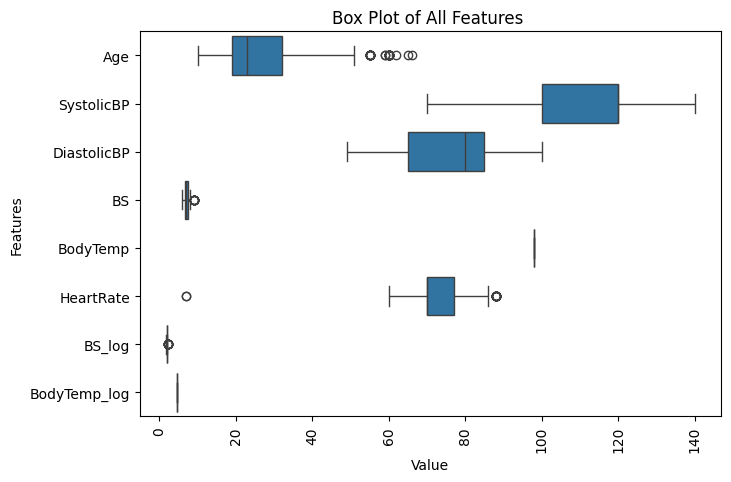

In [ ]:
# Melt the DataFrame
X_melted = X.melt(var_name='Features', value_name='Value')

# แสดง Box Plot สำหรับทุกคุณสมบัติ ยกเว้น Proline
plt.figure(figsize=(7.5, 5))
sns.boxplot(y='Features', x='Value', data=X_melted)
plt.xticks(rotation=90)
plt.title('Box Plot of All Features ')
plt.show()

In [ ]:
find_outliers_IQR(X, 'BS_log')

Q1 = 1.916922612182061
Q3 = 2.0149030205422647
IQR = 0.09798040836020361
Upper = 2.16
Lower = 1.7699519996417556
Outliers Upper Total = 10
Outliers Lower Total = 0


In [ ]:
find_outliers_IQR(X, 'BodyTemp_log')

Q1 = 4.584967478670572
Q3 = 4.584967478670572
IQR = 0.0
Upper = 4.58
Lower = 4.584967478670572
Outliers Upper Total = 0
Outliers Lower Total = 0


In [ ]:
# apply normalization techniques
# for column in X.BS:
#     X.BS_z = (X.BS - X.BS.mean()) / (X.BS.std())

X['BS_z'] = (X['BS'] - X['BS'].mean()) / X['BS'].std()

find_outliers_IQR(X, 'BS_z')

Q1 = -0.6347182584509119
Q3 = 0.5951172171822494
IQR = 1.2298354756331613
Upper = 2.44
Lower = -2.479471471900654
Outliers Upper Total = 10
Outliers Lower Total = 0


<ipython-input-72-7d391d529d0c>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['BS_z'] = (X['BS'] - X['BS'].mean()) / X['BS'].std()


In [ ]:
X['BodyTemp_z'] = (X['BodyTemp'] - X['BodyTemp'].mean()) / X['BodyTemp'].std()

find_outliers_IQR(X, 'BodyTemp_z')

Q1 = nan
Q3 = nan
IQR = nan
Upper = nan
Lower = nan
Outliers Upper Total = 0
Outliers Lower Total = 0


<ipython-input-73-99a98659ef5d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['BodyTemp_z'] = (X['BodyTemp'] - X['BodyTemp'].mean()) / X['BodyTemp'].std()


In [ ]:
X.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,BS_log,BodyTemp_log,BS_z,BodyTemp_z
3,30,140,85,7.00,98.0,70,1.945910,4.584967,-0.283337,NaN
4,35,120,60,6.10,98.0,76,1.808289,4.584967,-1.864554,NaN
5,23,140,80,7.01,98.0,70,1.947338,4.584967,-0.265768,NaN
6,23,130,70,7.01,98.0,78,1.947338,4.584967,-0.265768,NaN
8,32,120,90,6.90,98.0,70,1.931521,4.584967,-0.459027,NaN


In [ ]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X[['BS_RS', 'BodyTemp_RS']] = scaler.fit_transform(X[['BS', 'BodyTemp']])

<ipython-input-75-cc91a5560446>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['BS_RS', 'BodyTemp_RS']] = scaler.fit_transform(X[['BS', 'BodyTemp']])
<ipython-input-75-cc91a5560446>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['BS_RS', 'BodyTemp_RS']] = scaler.fit_transform(X[['BS', 'BodyTemp']])


In [ ]:
find_outliers_IQR(X, 'BS')

Q1 = 6.8
Q3 = 7.5
IQR = 0.7000000000000002
Upper = 8.55
Lower = 5.75
Outliers Upper Total = 10
Outliers Lower Total = 0


In [ ]:
find_outliers_IQR(X, 'BodyTemp')

Q1 = 98.0
Q3 = 98.0
IQR = 0.0
Upper = 98.00
Lower = 98.0
Outliers Upper Total = 0
Outliers Lower Total = 0


In [ ]:
X.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,BS_log,BodyTemp_log,BS_z,BodyTemp_z,BS_RS,BodyTemp_RS
3,30,140,85,7.00,98.0,70,1.945910,4.584967,-0.283337,NaN,0.000000,0.0
4,35,120,60,6.10,98.0,76,1.808289,4.584967,-1.864554,NaN,-1.285714,0.0
5,23,140,80,7.01,98.0,70,1.947338,4.584967,-0.265768,NaN,0.014286,0.0
6,23,130,70,7.01,98.0,78,1.947338,4.584967,-0.265768,NaN,0.014286,0.0
8,32,120,90,6.90,98.0,70,1.931521,4.584967,-0.459027,NaN,-0.142857,0.0


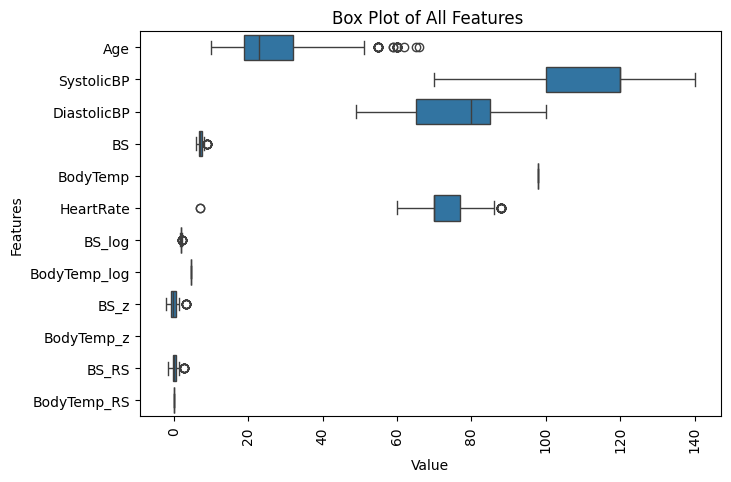

In [ ]:
# Melt the DataFrame
X_melted = X.melt(var_name='Features', value_name='Value')

# แสดง Box Plot สำหรับทุกคุณสมบัติ ยกเว้น Proline
plt.figure(figsize=(7.5, 5))
sns.boxplot(y='Features', x='Value', data=X_melted)
plt.xticks(rotation=90)
plt.title('Box Plot of All Features ')
plt.show()